In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

In [20]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/05_category_inflows.csv")

folios = pd.read_csv("../data/processed/06_industry_folio_count.csv")

perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")

tx = pd.read_csv("../data/processed/investor_transactions_clean.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

In [21]:
datasets = {
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Performance": perf,
    "Transactions": tx,
    "Holdings": holdings
}

for name, df in datasets.items():

    print("\n" + "="*50)

    print(name)

    print(df.shape)

    print(df.isnull().sum().sum())

    print(df.duplicated().sum())


NAV
(45962, 3)
27842
0

AUM
(90, 5)
0
0

SIP
(48, 6)
12
0

Category
(144, 3)
0
0

Folios
(21, 6)
0
0

Performance
(40, 19)
0
0

Transactions
(32778, 13)
0
0

Holdings
(322, 8)
0
0


In [35]:
top_funds = nav["amfi_code"].unique()[:10]

nav_top = nav[
    nav["amfi_code"].isin(top_funds)
]

fig = px.line(
    nav_top,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (Top 10 Funds)"
)

fig.show()

The top 10 mutual fund schemes demonstrated consistent NAV growth from 2022 to 2026, indicating positive long-term performance across the equity mutual fund market. Certain schemes, particularly those with higher NAV ranges, experienced stronger growth momentum during 2025–2026, reflecting improved market conditions and increased investor confidence. The recurring fluctuations visible in several schemes suggest periodic market volatility and regular valuation adjustments, which are common in equity-oriented mutual funds.

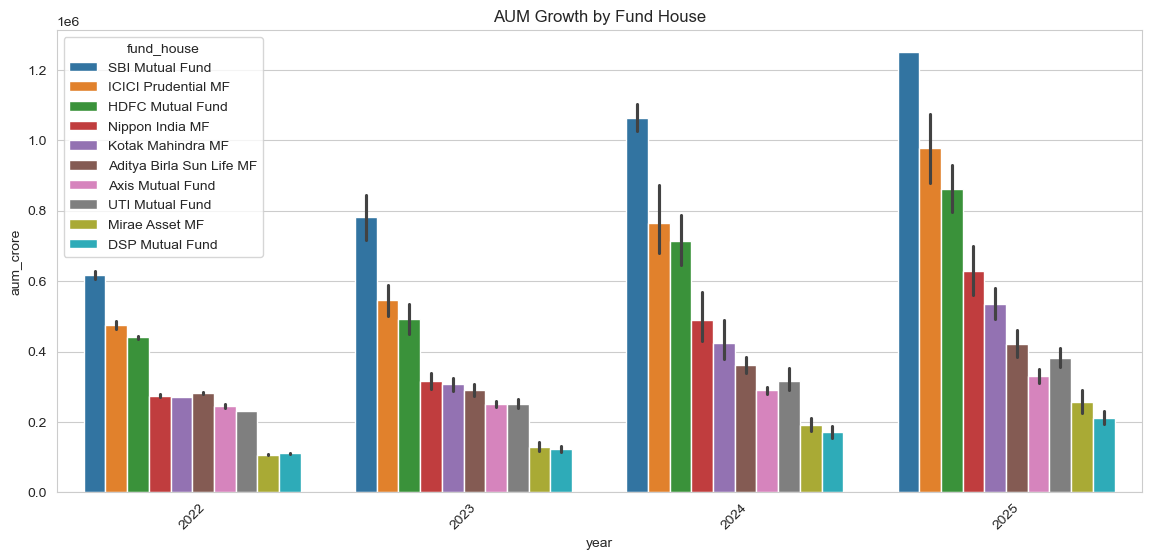

In [23]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.xticks(rotation=45)

plt.show()

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) across all years, demonstrating strong investor confidence and market leadership. Large fund houses such as ICICI Prudential and HDFC Mutual Fund also showed significant year-on-year AUM expansion.

In [24]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Trend"
)

fig.show()

Monthly SIP inflows showed strong and consistent growth from 2022 to 2025, reflecting increasing retail investor participation in mutual funds. SIP contributions accelerated significantly during 2024 and crossed ₹30,000 crore by late 2025, indicating growing investor confidence, higher financial awareness, and long-term investment adoption among Indian households.

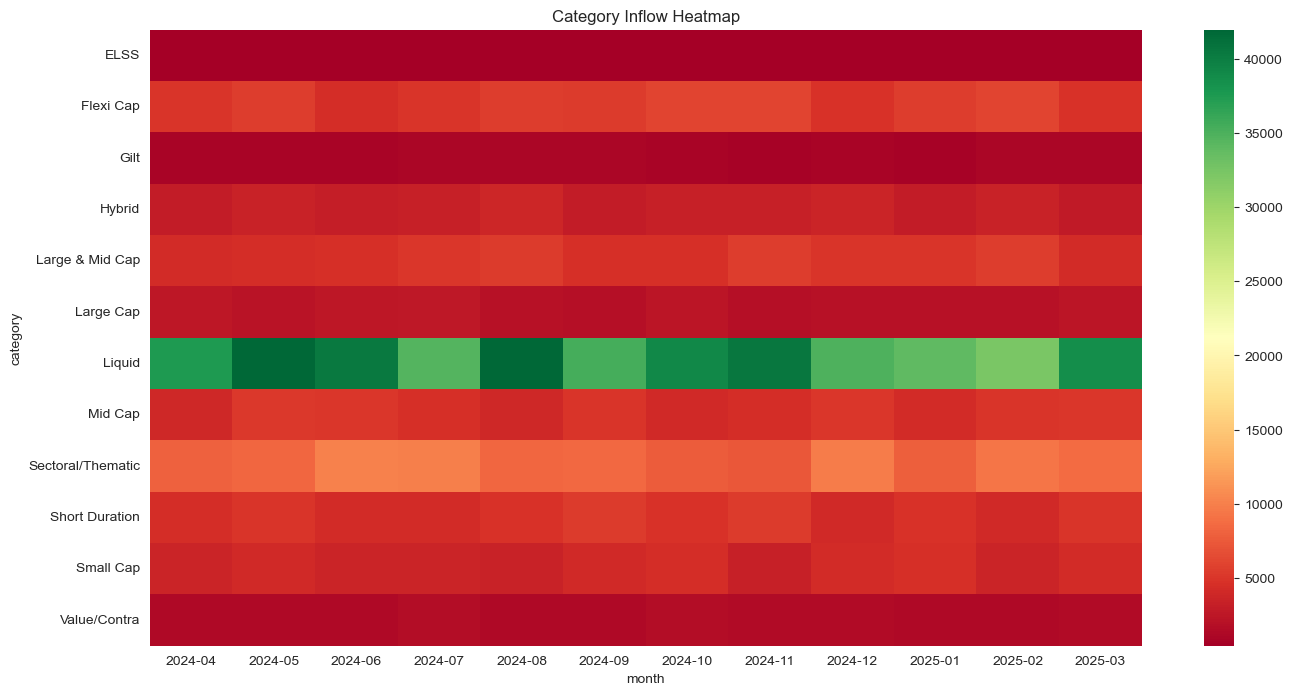

In [25]:
pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn"
)

plt.title("Category Inflow Heatmap")

plt.show()

Liquid funds attracted the highest inflows compared to other categories, indicating investor preference for low-risk and highly liquid investment options during uncertain market periods. Sectoral and thematic categories displayed comparatively moderate inflows.

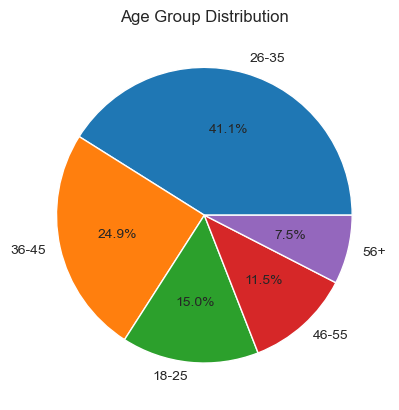

In [26]:
tx["age_group"].value_counts().plot.pie(
    autopct='%1.1f%%'
)

plt.title("Age Group Distribution")

plt.ylabel("")

plt.show()

The 26–35 age group represented the largest share of mutual fund investors, highlighting strong participation from young working professionals. Investors above 56 years formed the smallest segment.

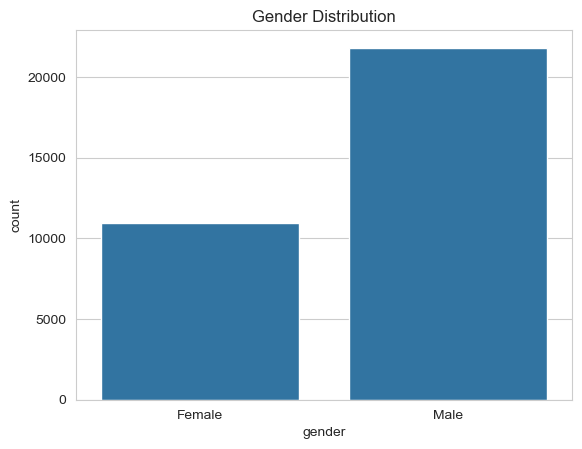

In [27]:
sns.countplot(
    data=tx,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

Male investors accounted for a significantly larger share of mutual fund participation compared to female investors, suggesting a noticeable gender gap in investment activity.

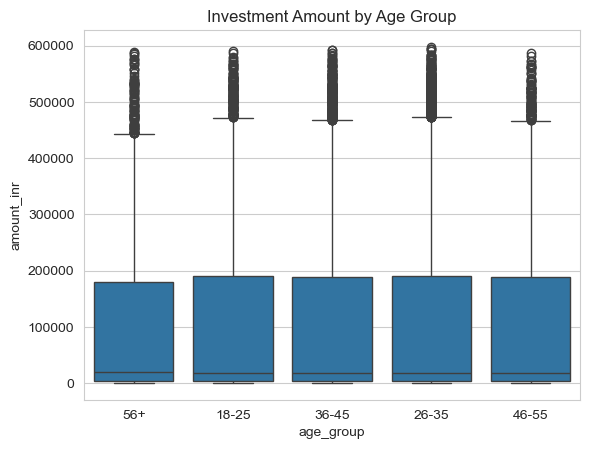

In [28]:
sns.boxplot(
    data=tx,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.show()

The 26–35 and 36–45 age groups showed higher investment ranges and greater variability in investment amounts, indicating stronger earning capacity and investment appetite among mid-career professionals.

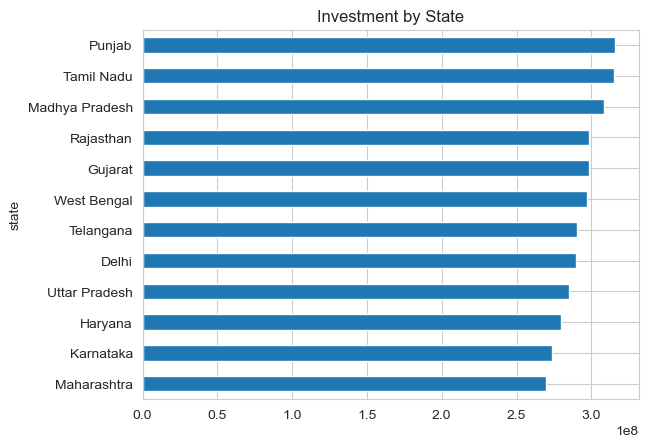

In [29]:
state_data = tx.groupby(
    "state"
)["amount_inr"].sum().sort_values()

state_data.plot.barh()

plt.title("Investment by State")

plt.show()

Punjab, Tamil Nadu, and Madhya Pradesh recorded the highest cumulative investment amounts among all states, reflecting strong regional participation in mutual fund investments.

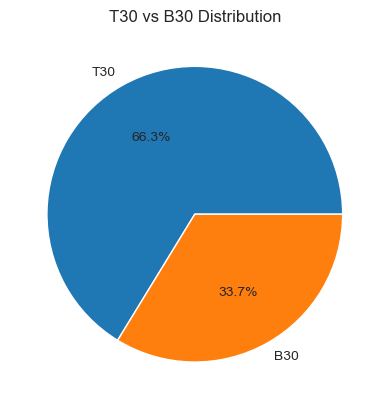

In [30]:
tx["city_tier"].value_counts().plot.pie(
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Distribution")

plt.ylabel("")

plt.show()

Approximately two-thirds of investors belonged to T30 cities, indicating that metropolitan regions still dominate mutual fund penetration. However, B30 participation also showed meaningful contribution, reflecting increasing financial awareness in smaller cities.

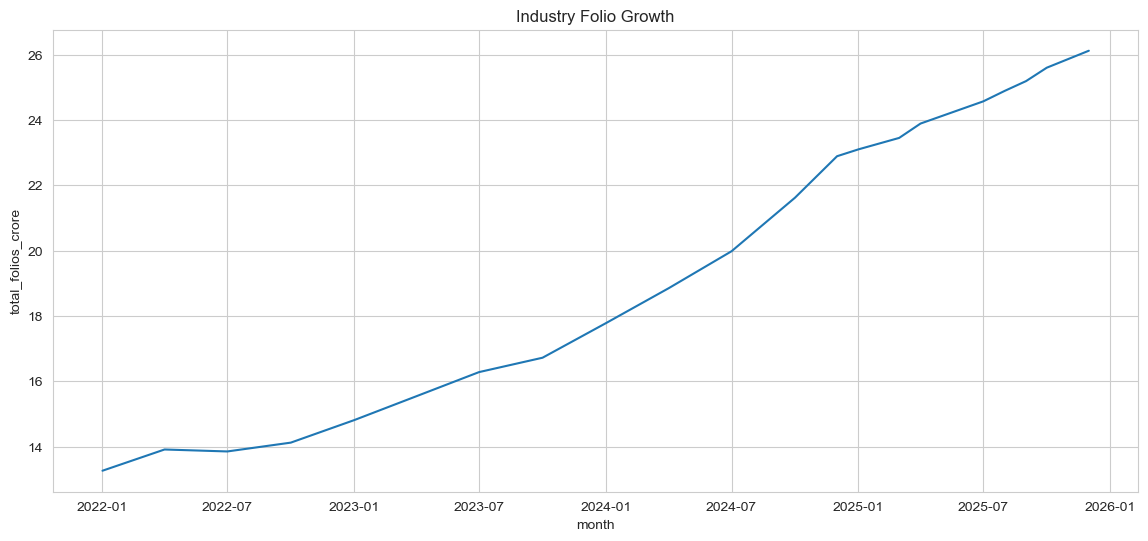

In [31]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=folios,
    x="month",
    y="total_folios_crore"
)

plt.title("Industry Folio Growth")

plt.show()

The total mutual fund folio count increased steadily from nearly 13 crore in 2022 to over 26 crore by the end of 2025, demonstrating rapid growth in retail investor participation across India.

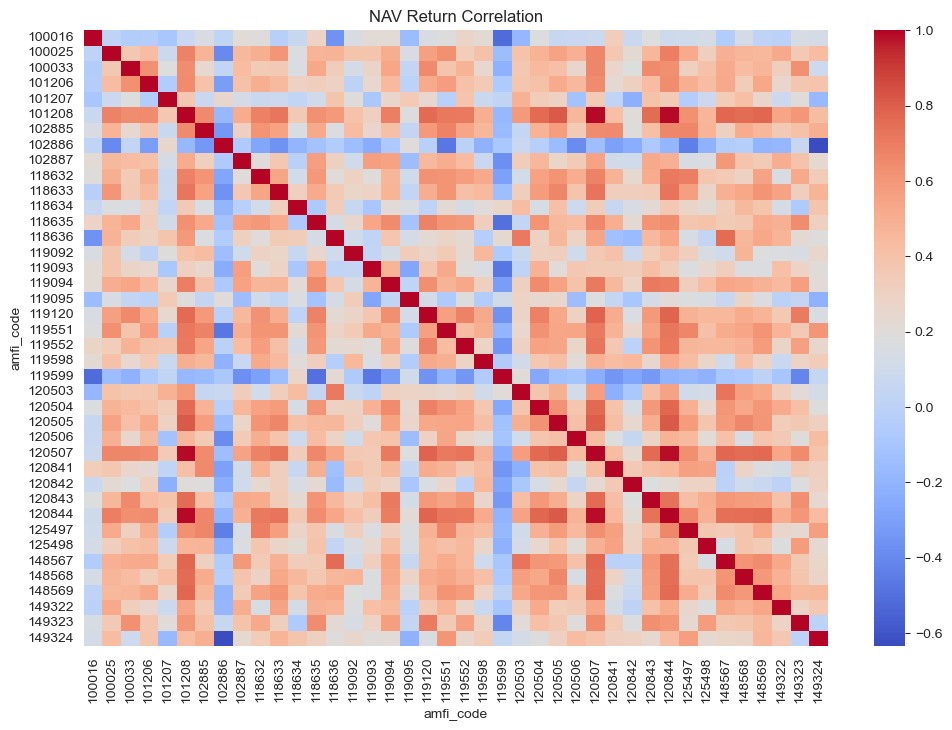

In [32]:
pivot_nav = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")

plt.show()

Most equity-oriented funds exhibited moderate to high positive correlation in returns, indicating that many schemes respond similarly to overall market movements and macroeconomic conditions.

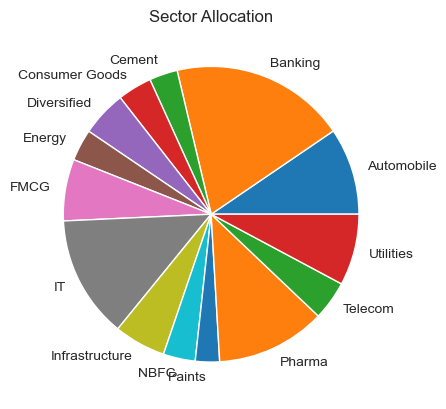

In [33]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

plt.pie(
    sector,
    labels=sector.index
)

plt.title("Sector Allocation")

plt.show()

Banking, IT, and Pharma sectors occupied a major portion of portfolio allocations, highlighting the dominance of financially strong and growth-oriented industries within mutual fund portfolios.

In [36]:
plt.savefig(
    "../reports/charts/chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [37]:
plt.savefig(
    "../reports/charts/sip_trend.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>